<a href="https://colab.research.google.com/github/Renyambar/Reny_MachineLearning/blob/main/JS06/JS06_Tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tugas 1 - SVM pada `voice.csv`
### Langkah 1 - Import Library & Load Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

df = pd.read_csv('voice.csv')
print(df.shape)
print(df['label'].value_counts())
df.head()

(3168, 21)
label
male      1584
female    1584
Name: count, dtype: int64


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


### Langkah 2 - Pra-pengolahan
Label di-encode (male=1, female=0). Fitur distandarisasi dengan `StandardScaler` (fit hanya pada data training) karena SVM sensitif terhadap skala fitur.

In [ ]:
X = df.drop(columns='label')
y = df['label'].map({'male': 1, 'female': 0})

### Langkah 3 - Model SVM: 3 kernel x 2 rasio split

In [ ]:
kernels = ['linear', 'poly', 'rbf']
splits = {'70:30': 0.3, '80:20': 0.2}

rows = []
for split_name, test_size in splits.items():
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size,
                                          random_state=42, stratify=y)
    scaler = StandardScaler().fit(Xtr)
    Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

    for k in kernels:
        model = SVC(kernel=k)
        model.fit(Xtr_s, ytr)
        rows.append({
            'Split': split_name,
            'Kernel': k,
            'Akurasi Train': accuracy_score(ytr, model.predict(Xtr_s)),
            'Akurasi Test': accuracy_score(yte, model.predict(Xte_s)),
        })

hasil1 = pd.DataFrame(rows)
hasil1

,Split,Kernel,Akurasi Train,Akurasi Test
0,70:30,linear,0.972034,0.978970
1,70:30,poly,0.966622,0.960042
2,70:30,rbf,0.983762,0.983176
3,80:20,linear,0.976717,0.974763
4,80:20,poly,0.968035,0.955836
5,80:20,rbf,0.983820,0.982650


### Langkah 4 - Tabulasi Akurasi (data testing)

In [ ]:
tabel1 = hasil1.pivot(index='Kernel', columns='Split', values='Akurasi Test')
tabel1 = (tabel1 * 100).round(2).add_suffix(' (%)')
tabel1

Split,70:30 (%),80:20 (%)
Kernel,,
linear,97.90,97.48
poly,96.00,95.58
rbf,98.32,98.26


**Analisis**
- Kernel RBF memberikan akurasi test tertinggi pada kedua split (sekitar 98,3%), diikuti kernel linear (sekitar 97,5-97,9%), sedangkan kernel polynomial paling rendah (sekitar 95,6-96,0%).
- Selisih antara split 70:30 dan 80:20 sangat kecil sehingga rasio split tidak banyak memengaruhi performa pada data ini.

## Tugas 2 - Klasifikasi Siang/Malam dengan SVM RBF
### Langkah 0 - Import Library

In [ ]:
from pathlib import Path
import matplotlib.image as mpimg
import cv2
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix

train_dir = 'images/training/'
test_dir = 'images/test/'

### Langkah 1 - Load Data

In [ ]:
def load_dataset(img_dir):
    p = Path(img_dir)
    img_list = []
    for d in sorted(p.glob('*')):
        label = d.name
        for file in sorted(d.glob('*.jpg')):
            img = mpimg.imread(file)
            if img is not None:
                img_list.append((img, label))
    return img_list

train_img = load_dataset(train_dir)
test_img = load_dataset(test_dir)
print(len(train_img), len(test_img))

240 160


### Langkah 2 - Pra-pengolahan (standarisasi ukuran & encoding label)

In [ ]:
def standarized_input(image):
    return cv2.resize(image, (1100, 600))

def label_encoder(label):
    return 1 if label == 'day' else 0   # day=1, night=0

def preprocess(img_list):
    return [(standarized_input(img), label_encoder(lbl)) for img, lbl in img_list]

# Praktikum membagi data training/test secara terpisah; karena tugas meminta rasio 80:20,
# seluruh gambar digabung lalu di-split ulang 80:20.
all_std = preprocess(train_img) + preprocess(test_img)
print(len(all_std))

400


### Langkah 3 - Ekstraksi Fitur Histogram
Histogram dihitung pada ruang warna HSV (seperti Lab 5), masing-masing kanal H, S, V dengan 16 bin dan dinormalisasi, sehingga 1 gambar menjadi vektor 48 fitur.

In [ ]:
BINS = 16

def hist_feature(image, bins=BINS):
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    feats = []
    for ch, rng in zip(range(3), [(0, 180), (0, 256), (0, 256)]):
        h = cv2.calcHist([hsv], [ch], None, [bins], list(rng)).ravel()
        feats.append(h / h.sum())
    return np.concatenate(feats)

X_img = np.array([hist_feature(img) for img, _ in all_std])
y_img = np.array([lbl for _, lbl in all_std])
print(X_img.shape, y_img.shape, 'day:', y_img.sum(), 'night:', (y_img == 0).sum())

(400, 48) (400,) day: 200 night: 200


### Langkah 4 - Split 80:20

In [ ]:
Xtr, Xte, ytr, yte = train_test_split(X_img, y_img, test_size=0.2,
                                      random_state=42, stratify=y_img)
print(Xtr.shape, Xte.shape)

(320, 48) (80, 48)


### Langkah 5 - Baseline SVM RBF (parameter default)

In [ ]:
base = make_pipeline(StandardScaler(), SVC(kernel='rbf'))
base.fit(Xtr, ytr)
print('Baseline (C=1, gamma=scale)')
print('Akurasi train:', accuracy_score(ytr, base.predict(Xtr)))
print('Akurasi test :', accuracy_score(yte, base.predict(Xte)))

Baseline (C=1, gamma=scale)
Akurasi train: 1.0
Akurasi test : 0.9875


### Langkah 6 - Hyperparameter Tuning (GridSearchCV) pada `C` dan `gamma`

In [ ]:
param_grid = {'svc__C': [0.1, 1, 10, 100, 1000],
              'svc__gamma': [1e-4, 1e-3, 1e-2, 1e-1, 'scale']}
grid = GridSearchCV(make_pipeline(StandardScaler(), SVC(kernel='rbf')),
                    param_grid,
                    cv=StratifiedKFold(5, shuffle=True, random_state=42),
                    n_jobs=-1)
grid.fit(Xtr, ytr)
print('Best params:', grid.best_params_)
print('Best CV accuracy:', grid.best_score_)

res = pd.DataFrame(grid.cv_results_)
res.pivot(index='param_svc__C', columns='param_svc__gamma', values='mean_test_score').round(4)

Best params: {'svc__C': 1, 'svc__gamma': 'scale'}
Best CV accuracy: 1.0


param_svc__gamma,0.0001,0.001,0.01,0.1,scale
param_svc__C,,,,,
0.1,0.8406,0.8375,0.9688,0.9250,0.9875
1.0,0.8406,0.9906,0.9844,0.9875,1.0000
10.0,0.9906,0.9844,0.9969,0.9906,1.0000
100.0,0.9844,1.0000,0.9969,0.9906,1.0000
1000.0,1.0000,1.0000,0.9969,0.9906,1.0000


### Langkah 7 - Evaluasi Model Terbaik

Akurasi train: 1.0000
Akurasi test : 0.9875
              precision    recall  f1-score   support

       night     0.9756    1.0000    0.9877        40
         day     1.0000    0.9750    0.9873        40

    accuracy                         0.9875        80
   macro avg     0.9878    0.9875    0.9875        80
weighted avg     0.9878    0.9875    0.9875        80



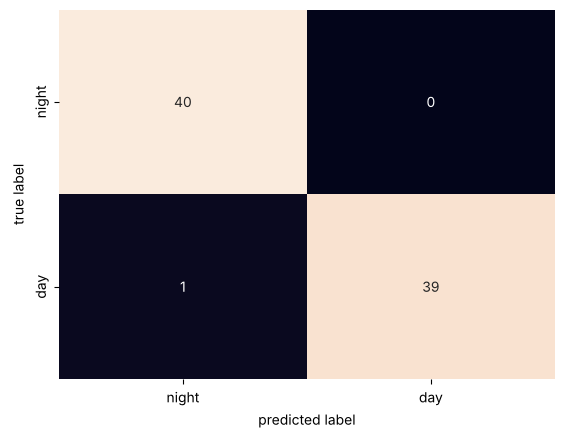

In [ ]:
best = grid.best_estimator_
y_pred = best.predict(Xte)

acc_train = accuracy_score(ytr, best.predict(Xtr))
acc_test = accuracy_score(yte, y_pred)
print(f'Akurasi train: {acc_train:.4f}')
print(f'Akurasi test : {acc_test:.4f}')
print(classification_report(yte, y_pred, target_names=['night', 'day'], digits=4))

sns.heatmap(confusion_matrix(yte, y_pred), annot=True, fmt='d', cbar=False,
            xticklabels=['night', 'day'], yticklabels=['night', 'day'])
plt.xlabel('predicted label'); plt.ylabel('true label'); plt.show()


- Fitur histogram HSV + SVM RBF memberikan akurasi test, baik dengan parameter default maupun hasil tuning.
- Hyperparameter terbaik: `C=1`, `gamma='scale'`. Beberapa kombinasi lain juga mencapai CV 100%, sehingga `GridSearchCV` memilih yang pertama ditemukan.
- Pada grid terlihat `gamma` yang terlalu kecil dengan `C` kecil menyebabkan underfitting.
- Dibanding Lab 5, fitur histogram yang lebih kaya meningkatkan akurasi.